In [62]:
import os 
import numpy as np
import PIL.Image as Image
import PIL.ImageOps as ImageOps
import matplotlib.pyplot as plt 
import pandas as pd
import math
import torch 
from torch.utils.data import Dataset , DataLoader , random_split
import torchvision.transforms as transforms

# **Section 1 : Data Preprocessing**

In [2]:
input_folder = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'
output_folder = '/kaggle/working/'
folder_1 = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/'

def get_files_as_dict(input_folder):
    files_dict = {'dirs':[] , "image" : [] , "mask" : []}
    for root , dirs , files in os.walk(input_folder):
        for file in files:
            if file.endswith('.tif'):
                if 'mask' not in file:
                    files_dict["image"].append(file)
                    mask_name = file.split(".")[0] + "_mask.tif"
                    files_dict["dirs"].append(root)
                    files_dict["mask"].append(mask_name)
    return files_dict


files_dict = get_files_as_dict(input_folder)

In [3]:
df = pd.DataFrame(files_dict)
df.to_csv(os.path.join(output_folder , "data_table.csv"))
df 

,dirs,image,mask
0,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7010_19860307_45.tif,TCGA_DU_7010_19860307_45_mask.tif
1,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7010_19860307_57.tif,TCGA_DU_7010_19860307_57_mask.tif
2,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7010_19860307_33.tif,TCGA_DU_7010_19860307_33_mask.tif
3,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7010_19860307_27.tif,TCGA_DU_7010_19860307_27_mask.tif
4,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7010_19860307_52.tif,TCGA_DU_7010_19860307_52_mask.tif
...,...,...,...
3924,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7306_19930512_32.tif,TCGA_DU_7306_19930512_32_mask.tif
3925,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7306_19930512_14.tif,TCGA_DU_7306_19930512_14_mask.tif
3926,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7306_19930512_20.tif,TCGA_DU_7306_19930512_20_mask.tif
3927,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,TCGA_DU_7306_19930512_36.tif,TCGA_DU_7306_19930512_36_mask.tif


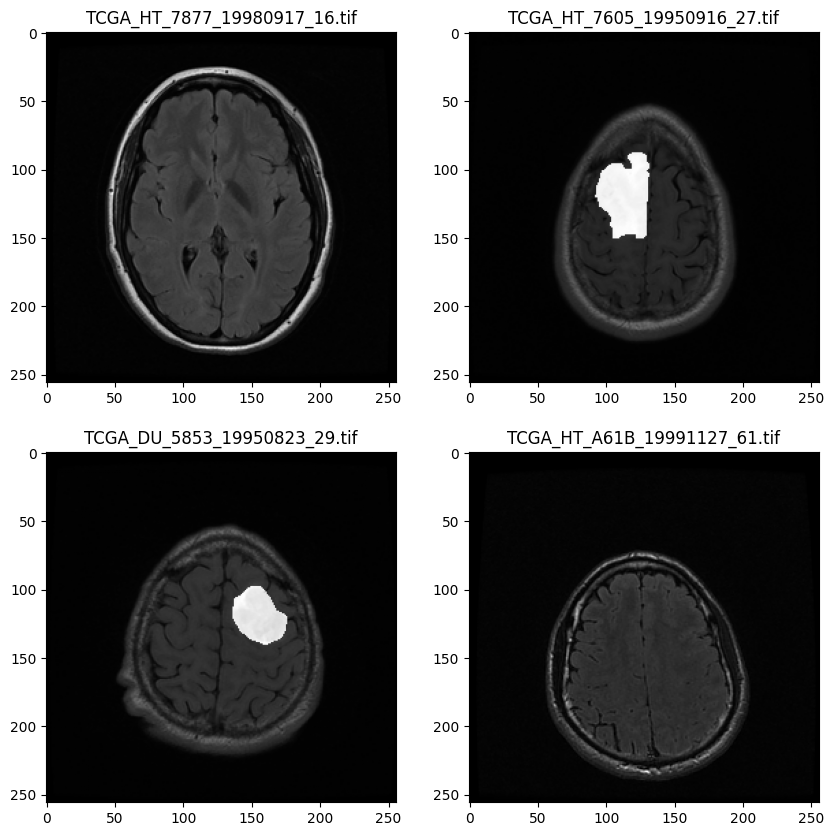

In [4]:
N = 4

def plot_images(images_df : pd.DataFrame , N = 5 , with_mask = True , seed = 1):
    m , n = images_df.shape
    
    np.random.seed(seed)
    random_indexes = np.random.randint(0 , m ,N)
    random_slices = images_df.loc[random_indexes].reset_index(drop = True)

    fig = plt.figure(figsize = (10 , 10))

    for i in range(N):
        ax = fig.add_subplot(2 , math.ceil(N / 2) , i + 1)
        directory = random_slices['dirs'][i]
        image = random_slices['image'][i]
        mask = random_slices['mask'][i]

        image_path = os.path.join(directory , image)
        mask_path = os.path.join(directory , mask)

        image_PIL = ImageOps.grayscale(Image.open(image_path))
        image_numpy = np.array(image_PIL)
        mask_numpy = np.array(Image.open(mask_path))
        
        if with_mask:
            mask = (mask_numpy > 0 ).astype('int') * 255
        else:
            mask = np.zeros(image_numpy.shape)

        ax.imshow(image_numpy  + mask , cmap = 'gray')
        ax.set_title(image)

plot_images(df , N = N , with_mask = True, seed = 5)

In [58]:
class MRIDataset(Dataset):
    def __init__(self , data_table : pd.DataFrame , Transform = None):
        self.data_table = data_table
        self.Transform = Transform

    def __len__(self):
        m , n = self.data_table.shape

        return m

    def __getitem__(self, idx):
        row = self.data_table.iloc[idx]
        dir_path = row["dirs"]
        image_path = os.path.join(dir_path , row['image'])
        mask_path = os.path.join(dir_path , row['mask'])

        image = ImageOps.grayscale(Image.open(image_path))
        if self.Transform:
            image = self.Transform(image)
            
        mask_tensor = torch.Tensor(np.array(Image.open(mask_path))).unsqueeze(0)
                
        return image , mask_tensor

In [63]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor()
])

dataset = MRIDataset(df , Transform = transform)
train_dataset , val_dataset , test_dataset = random_split(dataset , [0.8 , 0.1 , 0.1])

In [71]:
batch_size = 32
train_dataloader = DataLoader(train_dataset , batch_size = batch_size , shuffle = True)
val_dataloader = DataLoader(val_dataset , batch_size = batch_size , shuffle = False)
test_dataset = DataLoader(test_dataset , batch_size = batch_size , shuffle = False )

# **Section 2 : Model Building (U-Net)**